# Segmentation Basics

This notebook introduces the concepts of segmentations and uses the `CustomSegmentationDataLoader` class to view the image and the one-hot encoded mask.

In [1]:
import cv2
import glob as glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass

In [2]:
import requests
import zipfile


def download_file(url: str, save_path: Path) -> None:
    file = requests.get(url)
    open(save_path, "wb").write(file.content)


def unzip_file(zip_file):
    try:
        with zipfile.ZipFile(zip_file) as z:
            z.extractall("./")
            print("Extracted all files from ", zip_file)
    except:
        print("Invalid file: ", zip_file)


def download_unzip_file(url: str, save_path: Path):
    if not save_path.exists():
        download_file(url, save_path)
        unzip_file(save_path)

In [3]:
PARENT = Path().resolve()
DATASET = PARENT / "dataset.zip"
download_unzip_file(
    "https://www.dropbox.com/s/1g2y2nu9v7gizu9/dataset_SUIM.zip?dl=1", DATASET
)

In [4]:
@dataclass(frozen=True)
class DatasetConfig:
    IMG_HEIGHT: int = 256
    IMG_WIDTH: int = 256
    NUM_CLASSES: int = 6

    DATA_TRAIN_IMAGES = "dataset/train/images/*.jpg"
    DATA_TRAIN_LABELS = "dataset/train/masks/*.bmp"

    DATA_VALID_IMAGES = "dataset/valid/images/*.jpg"
    DATA_VALID_LABELS = "dataset/valid/masks/*.bmp"

    DATA_TEST_IMAGES = "dataset/test/images/*.jpg"
    DATA_TEST_LABELS = "dataset/test/masks/*.bmp"

In [5]:
import albumentations as A
from typing import List, Tuple, Dict

from keras.utils import Sequence


class CustomSegmentationDataLoader(Sequence):
    """
    Custom class for creating training and validation segmntation dataset objects.
    """

    def __init__(
        self,
        batch_size,
        image_size,
        image_paths,
        mask_paths,
        num_classes: int,
        should_augment_dataset: bool,
        classIDToColour: Dict,
    ):
        assert len(image_paths) == len(
            mask_paths
        ), f"The lenghts of the image_paths and mask_paths vary. Image: {len(image_paths)} Masks: {len(mask_paths)}"

        self.batch_size = batch_size
        self.image_size = image_size
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.num_classes = num_classes
        self.should_augment_dataset = should_augment_dataset
        self.classIDToColour = classIDToColour

        self.x = np.empty((self.batch_size,) + self.image_size + (3,), dtype=np.float32)
        self.y = np.empty((self.batch_size,) + self.image_size, dtype=np.float32)

        if self.should_augment_dataset:
            self.train_transforms = self.transforms()

        self.resize_transforms = self.resize()

    def __len__(self):
        """
        Returns the number of batches created for the dataset.
        """
        return len(self.image_paths) // self.batch_size

    def rgb_to_one_hot(self, rgb_image: np.ndarray):
        """
        Converts the RGB image to one-hot encoded images where the number of
        channels will be the same as the number of classes in the dataset.

        :param rgb_image: The mask image which needs to one-hot encoded.
        :type rgb_image: np.ndarray
        """
        shape = rgb_image.shape[:2] + (self.num_classes,)
        arr = np.zeros(shape, dtype=np.float32)

        for i in range(self.num_classes):
            arr[:, :, i] = np.all(
                rgb_image.reshape((-1, 3)) == self.classIDToColour[i], axis=1
            ).reshape(shape[:2])

        return arr

    def transforms(self):
        """
        Adds the augmentation transforms that will be applied on a dataset.
        Should typically be applied only on the training dataset.
        """

        return A.Compose(
            [
                A.HorizontalFlip(p=0.5),
                A.Affine(
                    scale=0.1,
                    rotate=0.2,
                    # shift_limit=0.2,
                    p=0.5,
                    border_mode=0,
                ),
            ]
        )

    def resize(self):
        """
        Add the resize transforms that will be applied on a dataset.
        """

        return A.Compose(
            [
                A.Resize(
                    height=self.image_size[0],
                    width=self.image_size[1],
                    interpolation=cv2.INTER_NEAREST,
                    p=1,
                )
            ]
        )

    def reset_batch(self):
        self.x.fill(0.0)
        self.y.fill(0.0)

    def __getitem__(self, batchIndex: int) -> Tuple:
        """
        Gets the batch associated at the provided index.

        :param batchIndex: The index at which the associated batch should be returned.
        :type batchIndex: int

        :return: Returns a tuple of list of images and the associated mask.
        The image is of shape [HEIGHT, WIDTH, 3] and the mask is of shape [HEIGHT, WIDTH].
        :rtype: Tuple
        """
        self.reset_batch()

        startIndex = batchIndex * self.batch_size
        for idx, (img_path, mask_path) in enumerate(
            zip(
                self.image_paths[startIndex : startIndex + self.batch_size],
                self.mask_paths[startIndex : startIndex + self.batch_size],
            )
        ):
            # Read the image and mask and convert to RGB format.
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            mask = cv2.imread(mask_path)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

            # Resize the image and mask.
            resized = self.resize_transforms(image=img, mask=mask)
            img, mask = resized["image"], resized["mask"]

            # Augment the image and mask, if it should.
            if self.should_augment_dataset:
                augmented = self.train_transforms(image=img, mask=mask)
                img, mask = augmented["image"], augmented["mask"]

            # Store the normalised image in X.
            self.x[idx] = img / 255

            # Convert the RGB segmentation mask to multi-channel (one-hot encoded)
            # arrays where each channel represents a single pixel whose pixel
            # values are either 0 or 1.
            # 1 represents a pixel location associated with the class
            # that corresponds to the channel.
            mask = self.rgb_to_one_hot(mask)

            # Convert the multi-channel mask to a single channel (grayscale)
            # representation whose values contain the classIDs for each class,
            # essentially collapsing the one-hot encoded arrays into a single channel.
            self.y[idx] = mask.argmax(-1)

        return self.x, self.y

In [6]:
classIDToColour = {
    0: (0, 0, 0),  # BW: Background/waterbody
    1: (0, 0, 255),  # HD: Human divers
    2: (0, 255, 255),  # WR: Wrecks and ruins
    3: (255, 0, 0),  # RO: Robots and instruments
    4: (255, 0, 255),  # RI: Reefs and invertebartes
    5: (255, 255, 0),  # FV: Fish and vertebrates
}

In [7]:
# Function to convert a single channel mask representation to an RGB mask.
def num_to_rgb(num_arr):

    single_layer = np.squeeze(num_arr)
    output = np.zeros(num_arr.shape[:2] + (3,))

    for k in classIDToColour.keys():
        output[single_layer == k] = classIDToColour[k]

    return (
        np.float32(output) / 255.0
    )  # return a floating point array in range [0.0, 1.0]

In [8]:
alpha = 1.0  # Transparency for the original image.
beta = 0.7  # Transparency for the segmentation map.
gamma = 0.0  # Scalar added to each sum.


# Function to overlay a segmentation map on top of an RGB image.
def image_overlay(image, segmented_image):
    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return np.clip(image, 0.0, 1.0)

In [9]:
def display_image_and_mask(data_list, color_mask=False):

    plt.figure(figsize=(16, 6))
    title = ["GT Image", "GT Mask", "Overlayed Mask"]

    grayscale_gt_mask = data_list[1]

    # Create RGB segmentation map from grayscale segmentation map.
    rgb_gt_mask = num_to_rgb(data_list[1])

    # Create the overlayed image.
    overlayed_image = image_overlay(data_list[0], rgb_gt_mask)

    data_list.append(overlayed_image)

    for i in range(len(data_list)):
        plt.subplot(1, len(data_list), i + 1)
        plt.title(title[i])
        if title[i] == "GT Mask":
            if color_mask:
                plt.imshow(np.array(rgb_gt_mask))
            else:
                plt.imshow(np.array(grayscale_gt_mask))
        else:
            plt.imshow(np.array(data_list[i]))
        plt.axis("off")

    plt.show()

In [10]:
def create_datasets(should_augment_training_dataset=False):
    # Training image and mask paths.
    train_images = sorted(glob.glob(f"{DatasetConfig.DATA_TRAIN_IMAGES}"))
    train_masks = sorted(glob.glob(f"{DatasetConfig.DATA_TRAIN_LABELS}"))

    # Validation image and mask paths.
    valid_images = sorted(glob.glob(f"{DatasetConfig.DATA_VALID_IMAGES}"))
    valid_masks = sorted(glob.glob(f"{DatasetConfig.DATA_VALID_LABELS}"))

    # Train data loader.
    train_ds = CustomSegmentationDataLoader(
        batch_size=8,
        image_size=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
        image_paths=train_images,
        mask_paths=train_masks,
        num_classes=DatasetConfig.NUM_CLASSES,
        should_augment_dataset=should_augment_training_dataset,
        classIDToColour=classIDToColour,
    )
    # Validation data loader.
    valid_ds = CustomSegmentationDataLoader(
        batch_size=8,
        image_size=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
        image_paths=valid_images,
        mask_paths=valid_masks,
        num_classes=DatasetConfig.NUM_CLASSES,
        should_augment_dataset=False,
        classIDToColour=classIDToColour,
    )

    return train_ds, valid_ds

In [11]:
train_ds, valid_ds = create_datasets(should_augment_training_dataset=True)

38


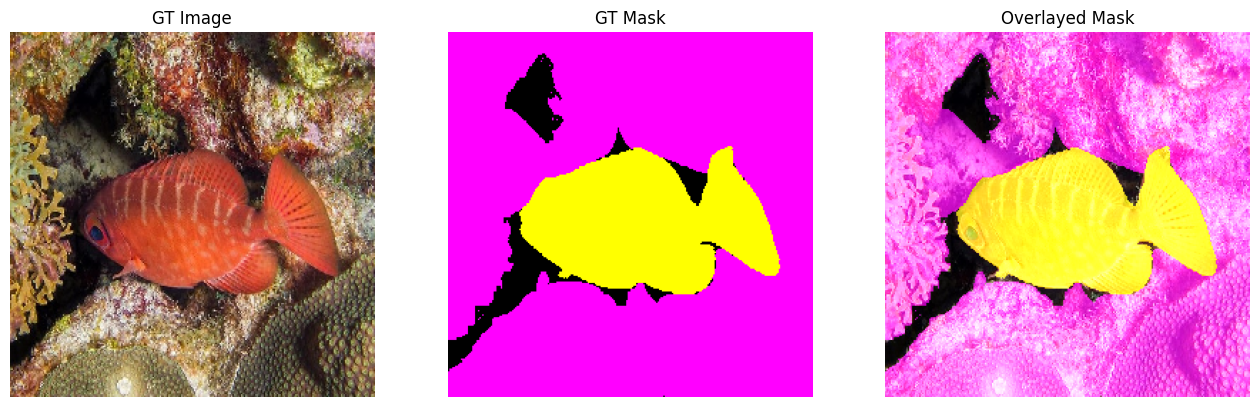

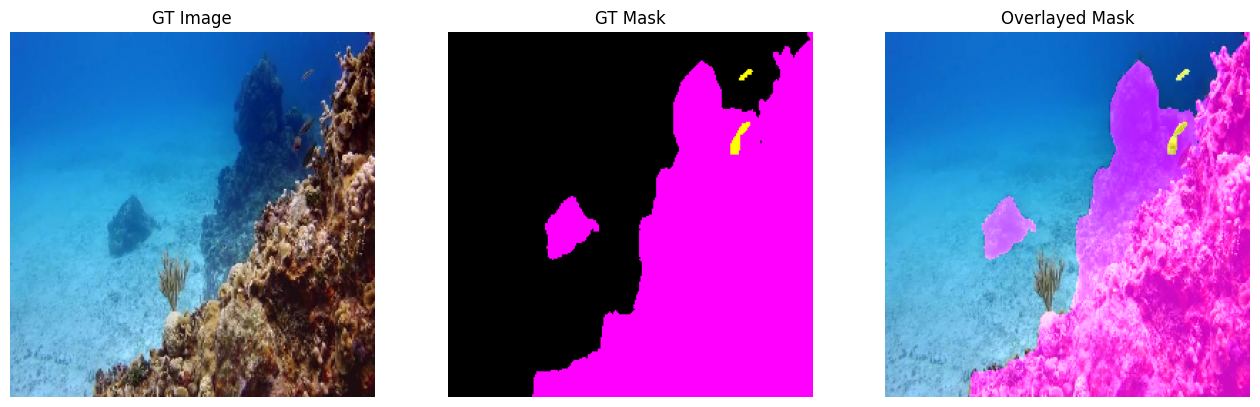

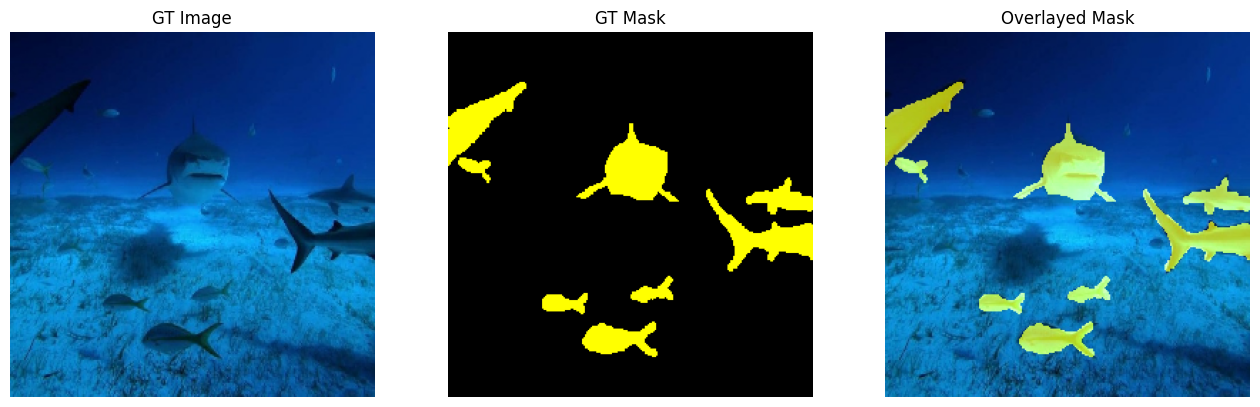

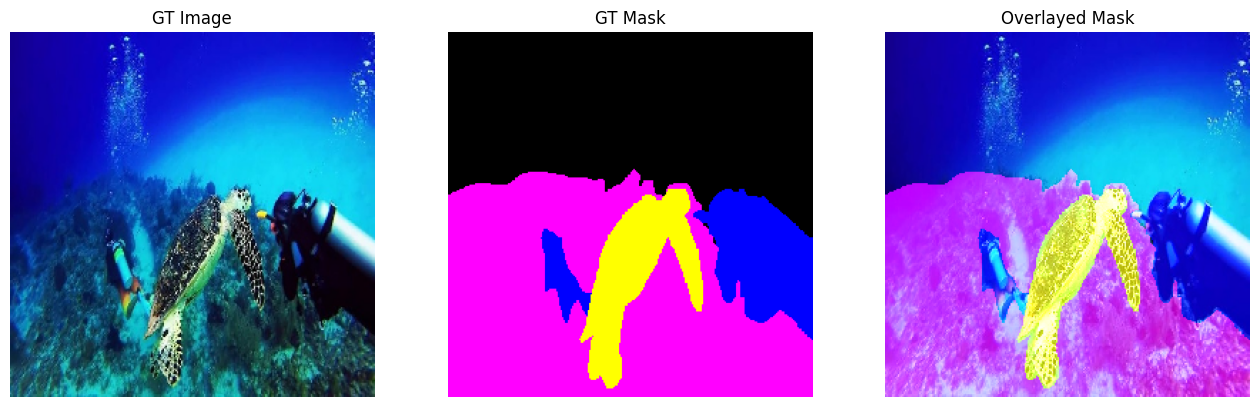

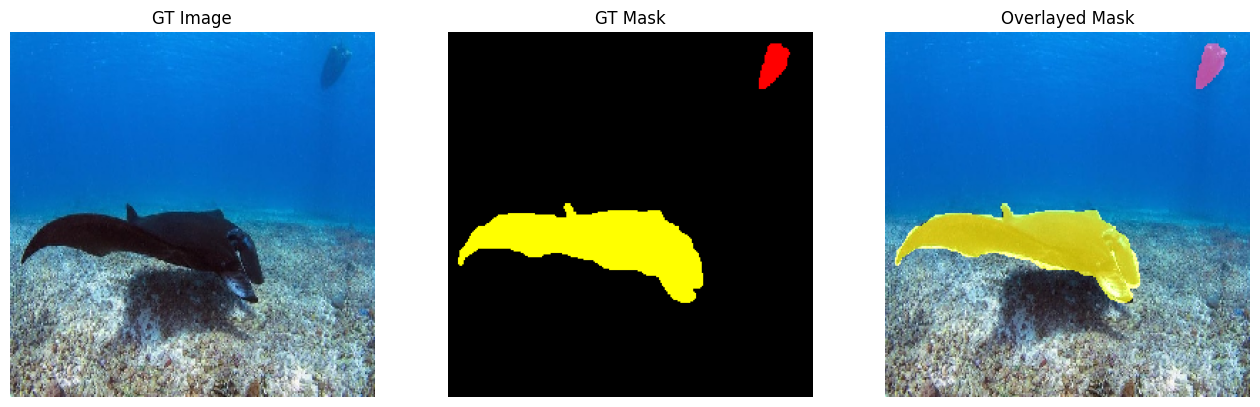

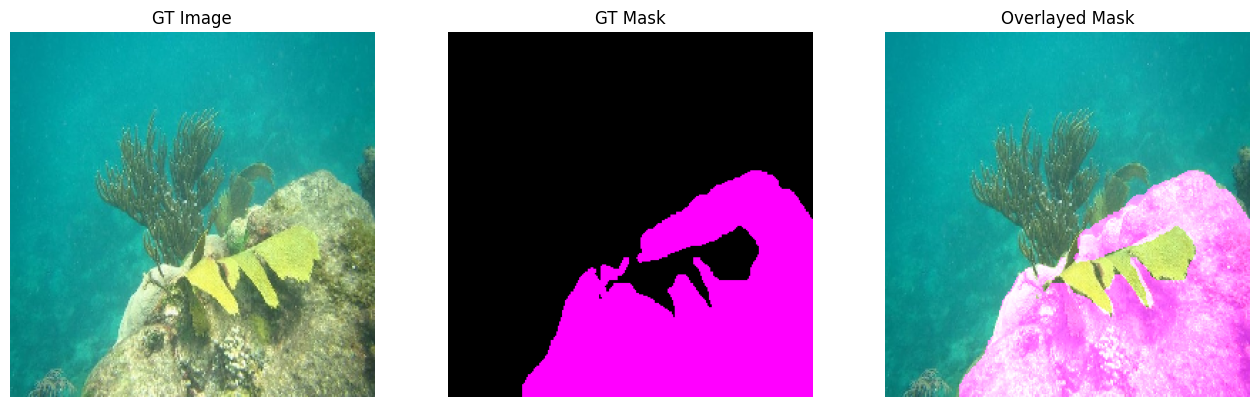

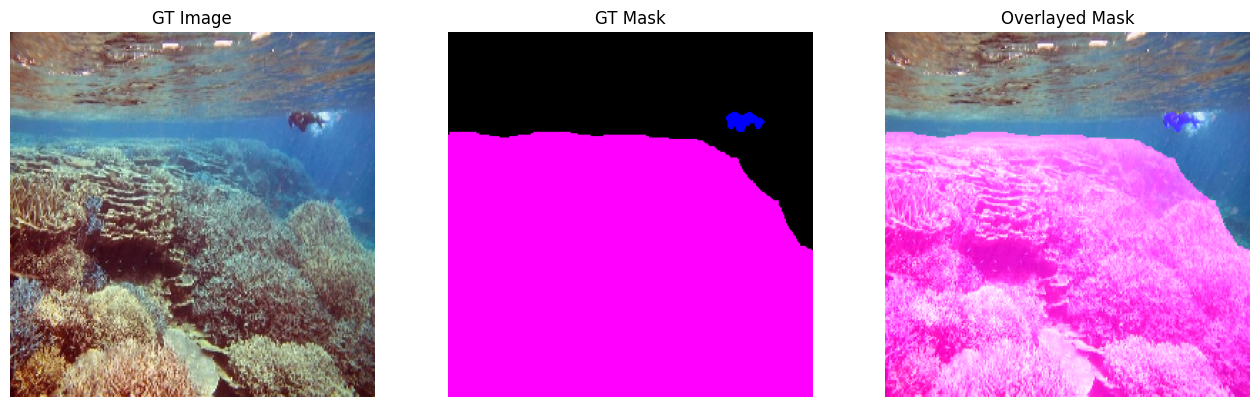

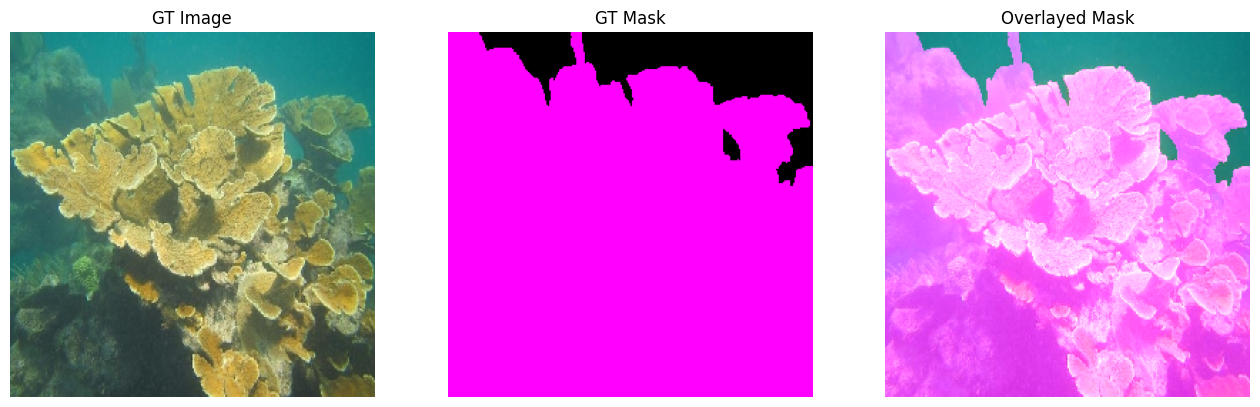

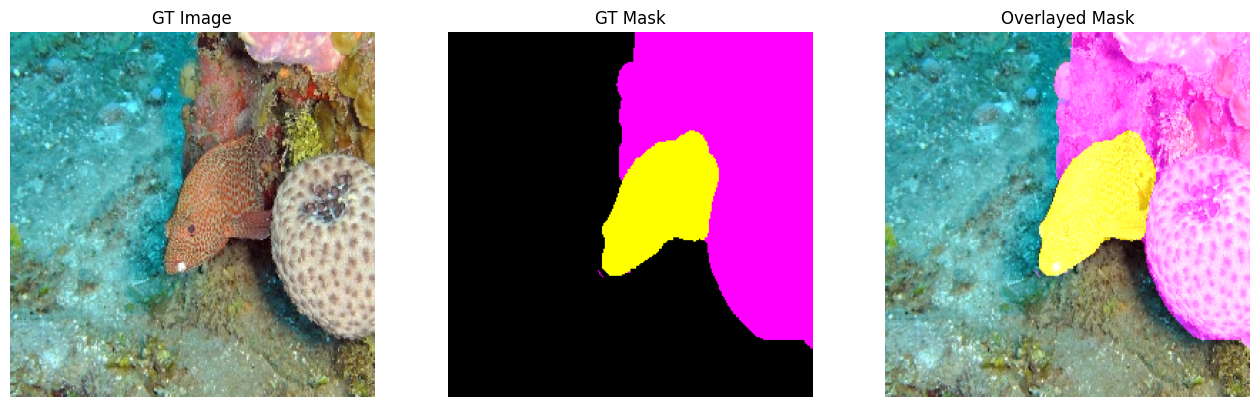

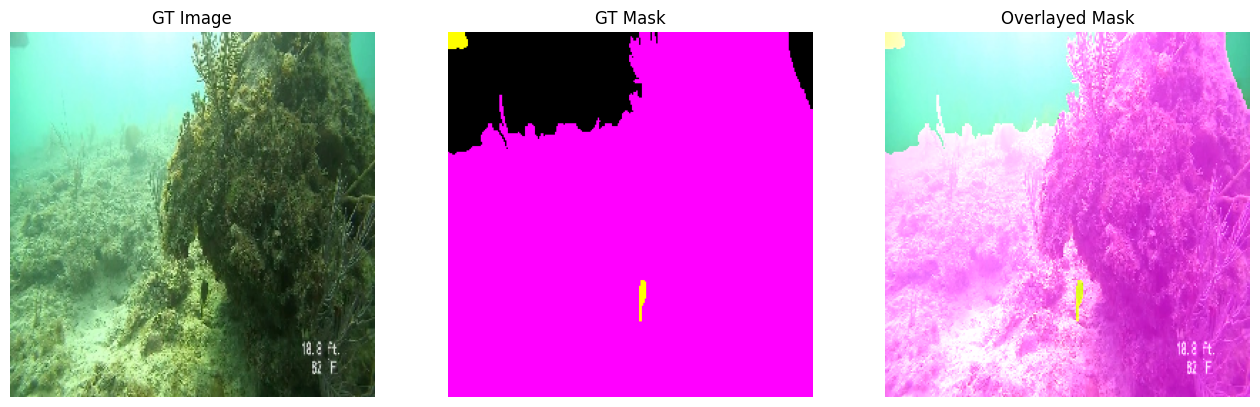

In [12]:
print(len(valid_ds))
for i, (images, masks) in enumerate(valid_ds):
    if i == 10:
        break
    # Retrieve last image in data batch as an example.
    image, mask = images[-1], masks[-1]
    display_image_and_mask([image, mask], color_mask=True)